In [ ]:
                                                                SECTION - 1 - IMPORTS

In [69]:
# PART 0: IMPORTS & GLOBAL PATH SETTINGS

# iMPORT libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modelling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [70]:
# PART 1: LOAD RAW DATASET

# Load data
df = pd.read_csv("D:\group_19\V3\online_shoppers_intention.csv")

In [ ]:
                                                    SECTION 2 - EXPLORATORY DATA ANALYSIS (EDA)

In [71]:
# PART 2: EXPLORATORY DATA ANALYSIS (EDA)

# 2.1: BASIC STRUCTURE 

 # Basic structure
print("Shape of raw dataset:", df.shape)

print("\nData types:")
print(df.dtypes)

df.tail()

Shape of raw dataset: (12330, 18)

Data types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


In [72]:
# 2.2: MISSING VALUES & DUPLICATES

# Quick summary
print(df.info())

#Missing values
print("\nMissing values per column:")
print(df.isna().sum())
 
#Duplicate values
print("\nDuplicate values existing:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           


--- Month ---
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64


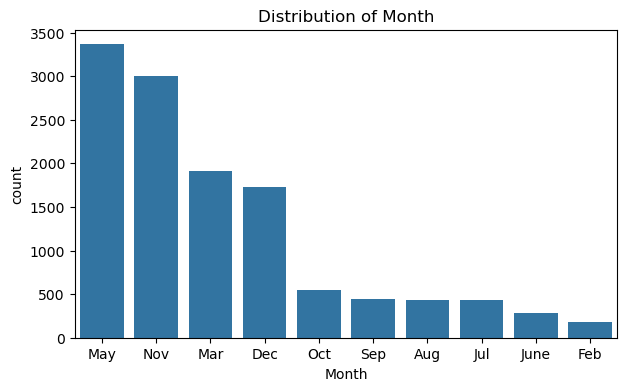


--- VisitorType ---
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64


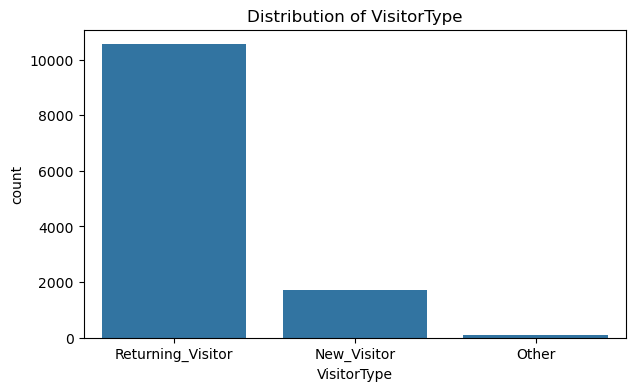


--- Weekend ---
Weekend
False    9462
True     2868
Name: count, dtype: int64


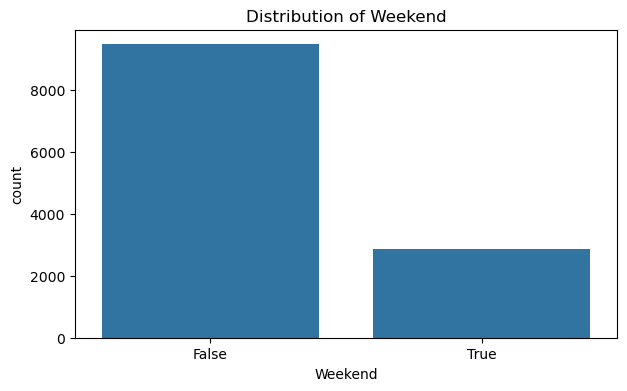

Revenue
0    10422
1     1908
Name: count, dtype: int64


In [73]:
 # 2.3: CATEGORICAL VARIABLE EXPLORATION

# Convert to category dtype

cat_cols = ['Month', 'VisitorType', 'Weekend'] 
for col in cat_cols:
    df[col] = df[col].astype('category')
  

# Now handling Revenue separately:
df['Revenue'] = df['Revenue'].astype(int)

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

    plt.figure(figsize=(7,4))
    sns.countplot(
        x=col,
        data=df,
        order=df[col].value_counts().index
    )
    plt.title(f"Distribution of {col}")
    plt.show()

print(df['Revenue'].value_counts())

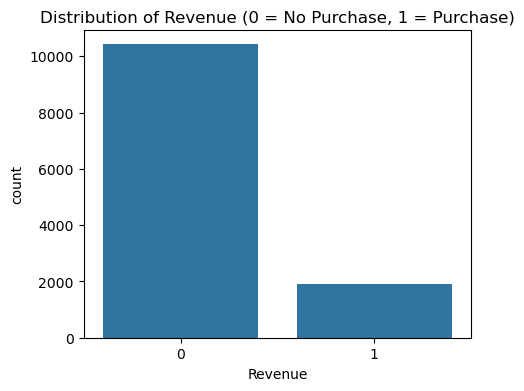

In [74]:
#visualizing Revenue count

plt.figure(figsize=(5,4))
sns.countplot(x='Revenue', data=df)
plt.title("Distribution of Revenue (0 = No Purchase, 1 = Purchase)")
plt.show()

In [75]:
# 2.4: NUMERICAL VARIABLE SUMMARY + SHAPE

num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


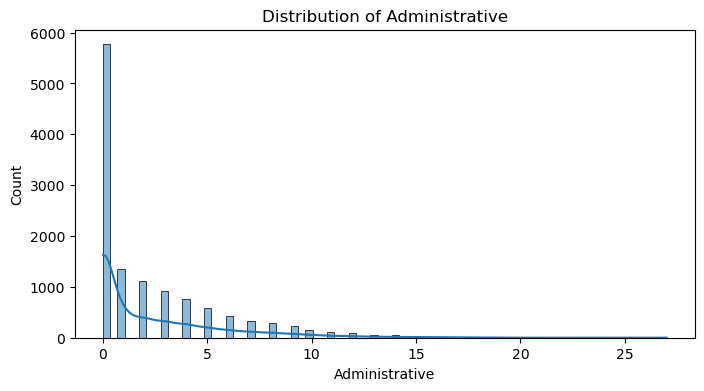

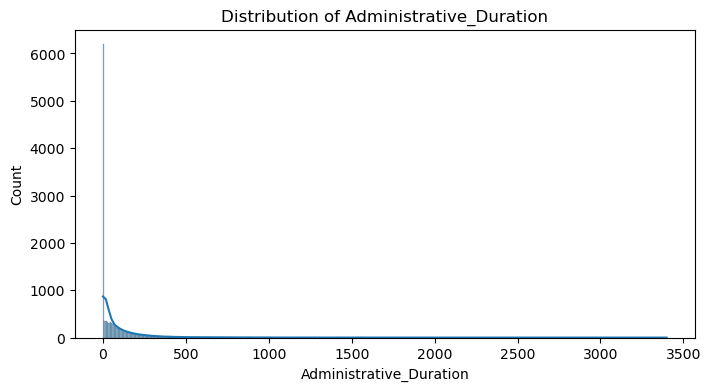

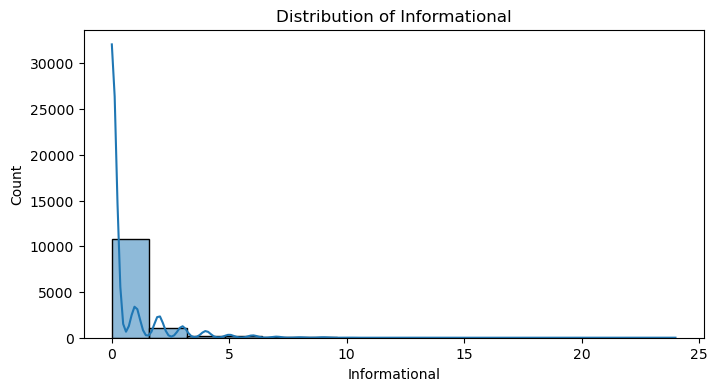

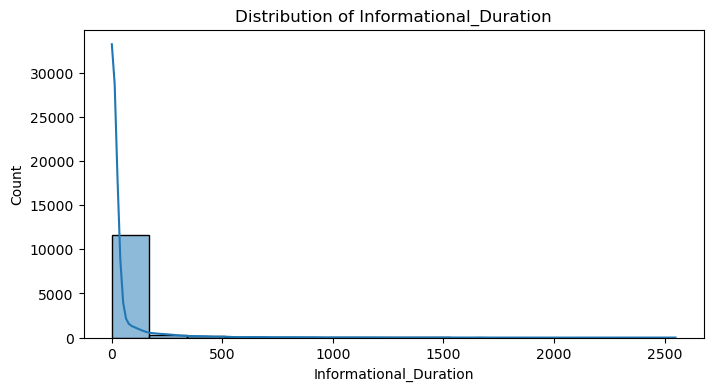

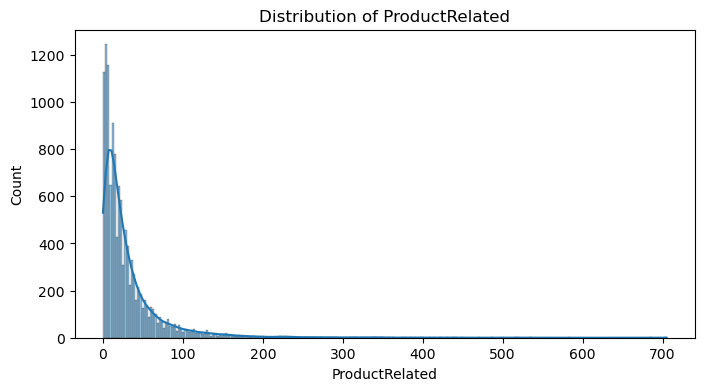

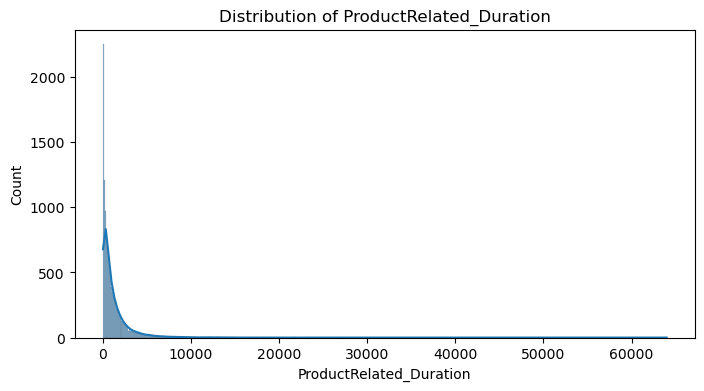

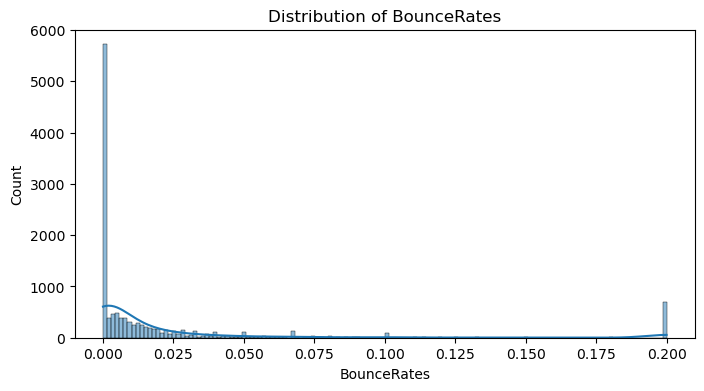

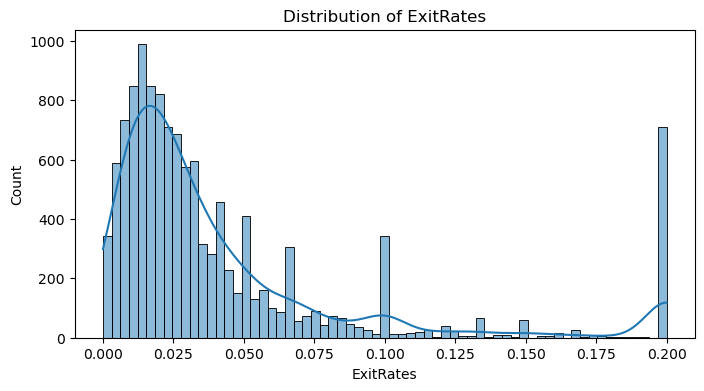

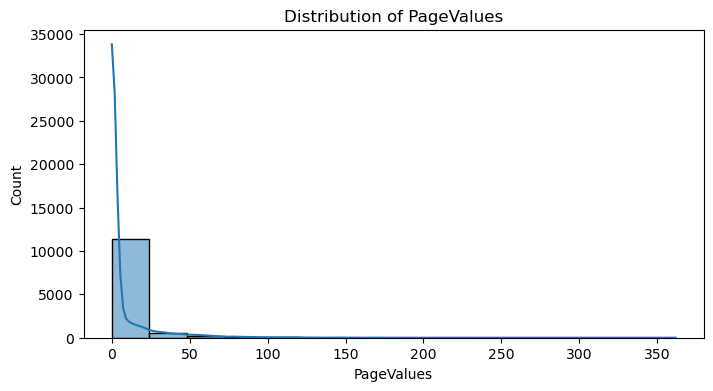

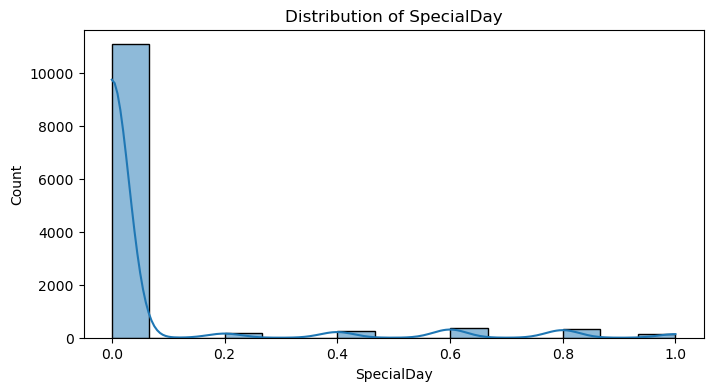

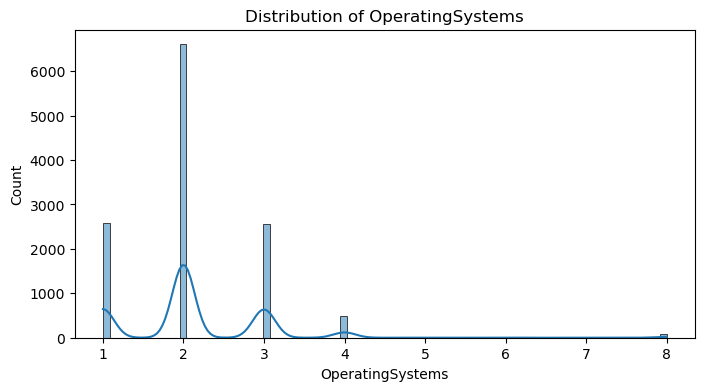

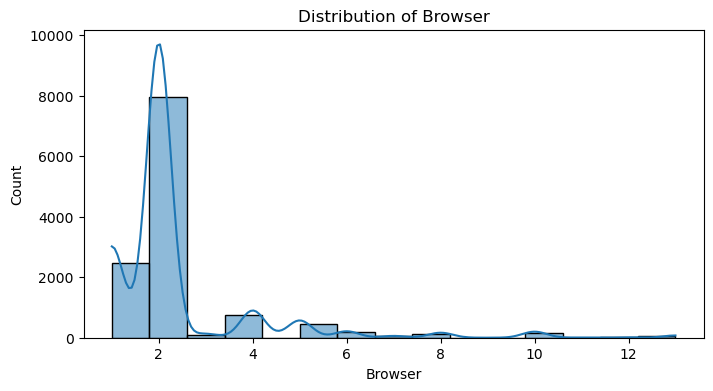

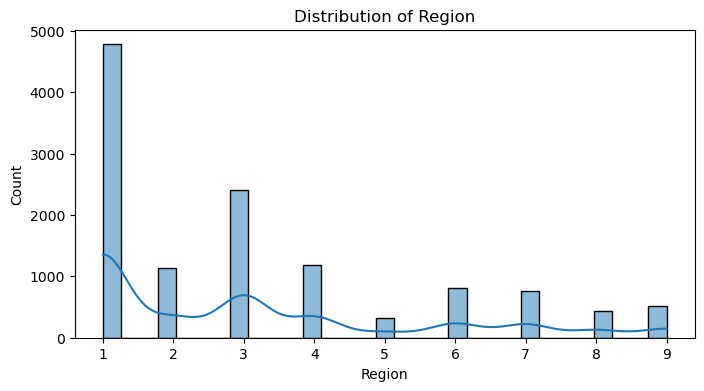

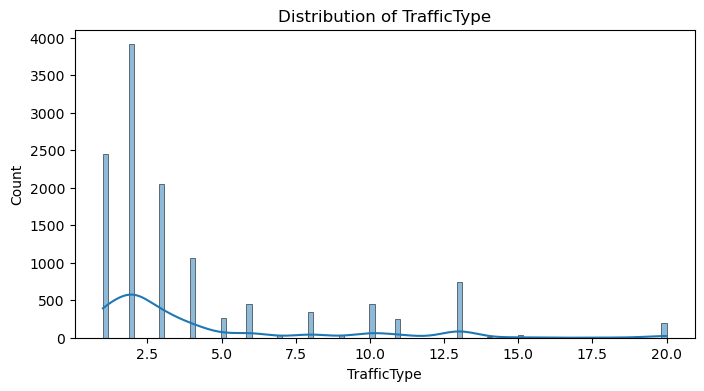

In [76]:
# 2.5: DISTRIBUTION ANALYSIS (Histogram)

# Identify numeric columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Plot histograms of numeric features

for col in num_cols:
    if col != 'Revenue':              
        plt.figure(figsize=(8,4))
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

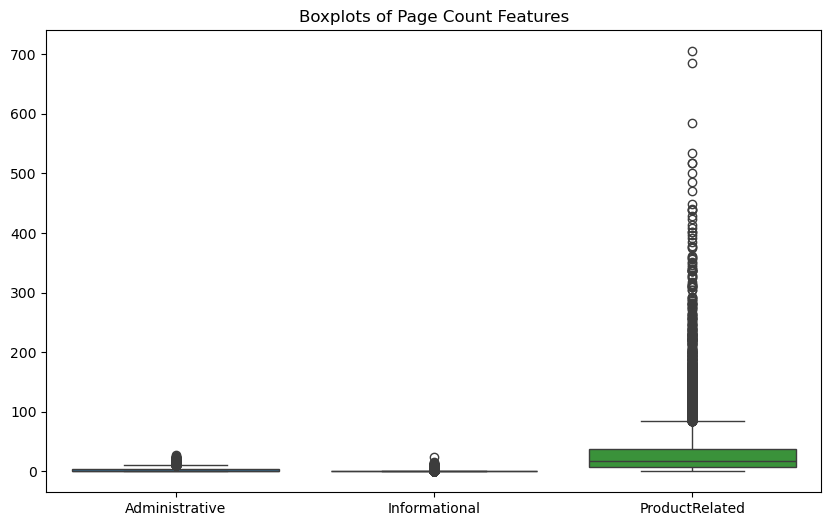

In [77]:
# 2.6: BOX PLOTS FOR OUTLIER DISCOVERY

  #Grouped Boxplots by Feature Type

#Define groups
page_count_cols = ['Administrative', 'Informational', 'ProductRelated']
duration_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']
rate_cols = ['BounceRates', 'ExitRates']
value_cols = ['PageValues', 'SpecialDay']

  #1️ Page Count Boxplots

plt.figure(figsize=(10,6))
sns.boxplot(data=df[page_count_cols])
plt.title("Boxplots of Page Count Features")
plt.show()

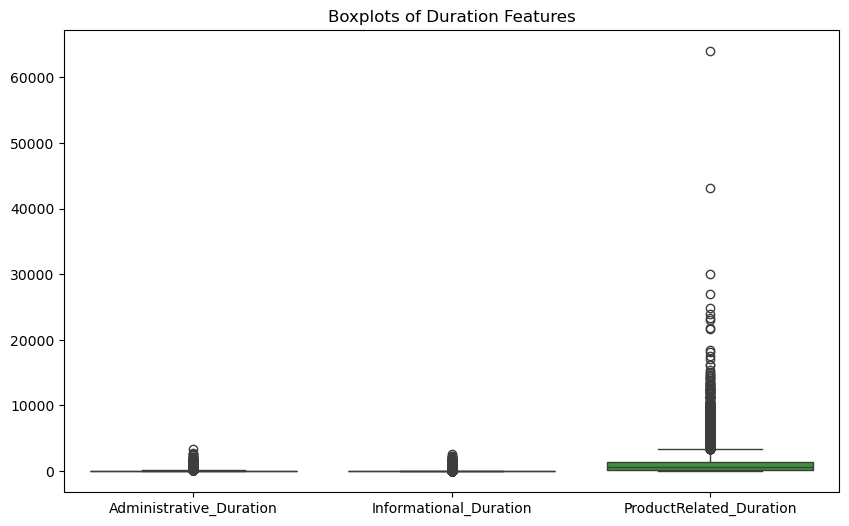

In [78]:
 #2️ Duration Boxplots

plt.figure(figsize=(10,6))
sns.boxplot(data=df[duration_cols])
plt.title("Boxplots of Duration Features")
plt.show()

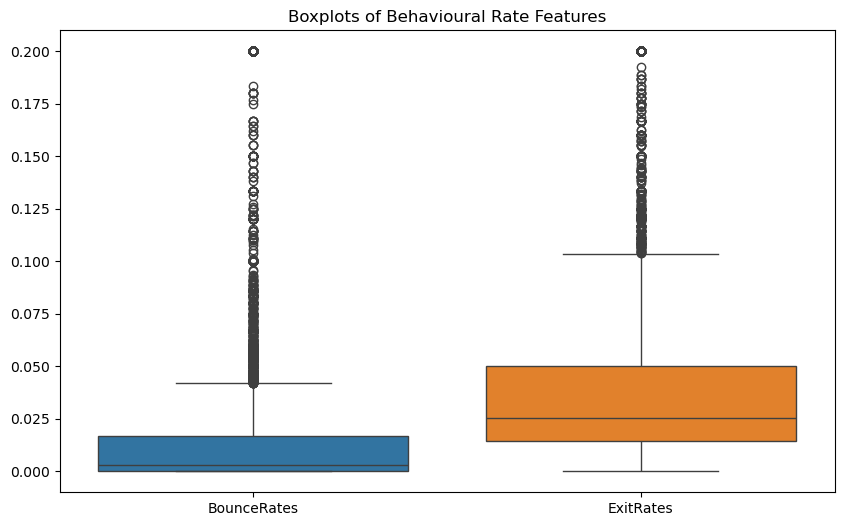

In [17]:
 # 3️ Behaviour Rate Boxplots

plt.figure(figsize=(10,6))
sns.boxplot(data=df[rate_cols])
plt.title("Boxplots of Behavioural Rate Features")
plt.show()

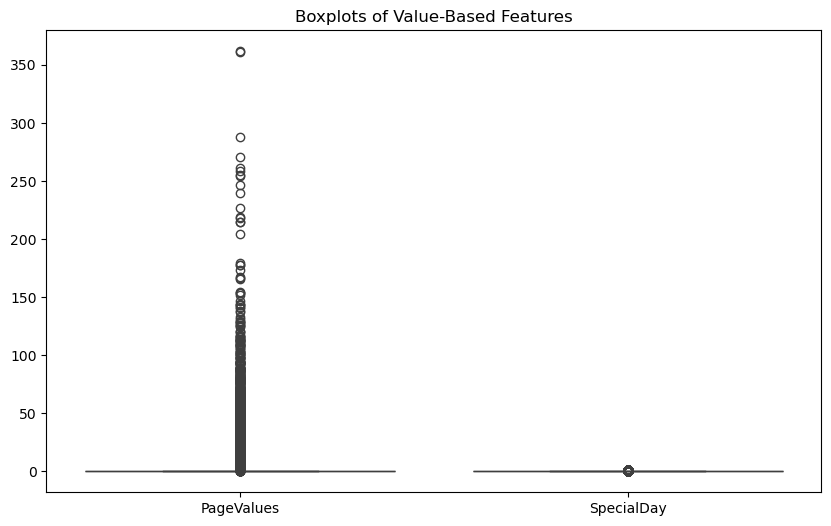

In [22]:
 #4️ Value Feature Boxplots

plt.figure(figsize=(10,6))
sns.boxplot(data=df[value_cols])
plt.title("Boxplots of Value-Based Features")
plt.show()

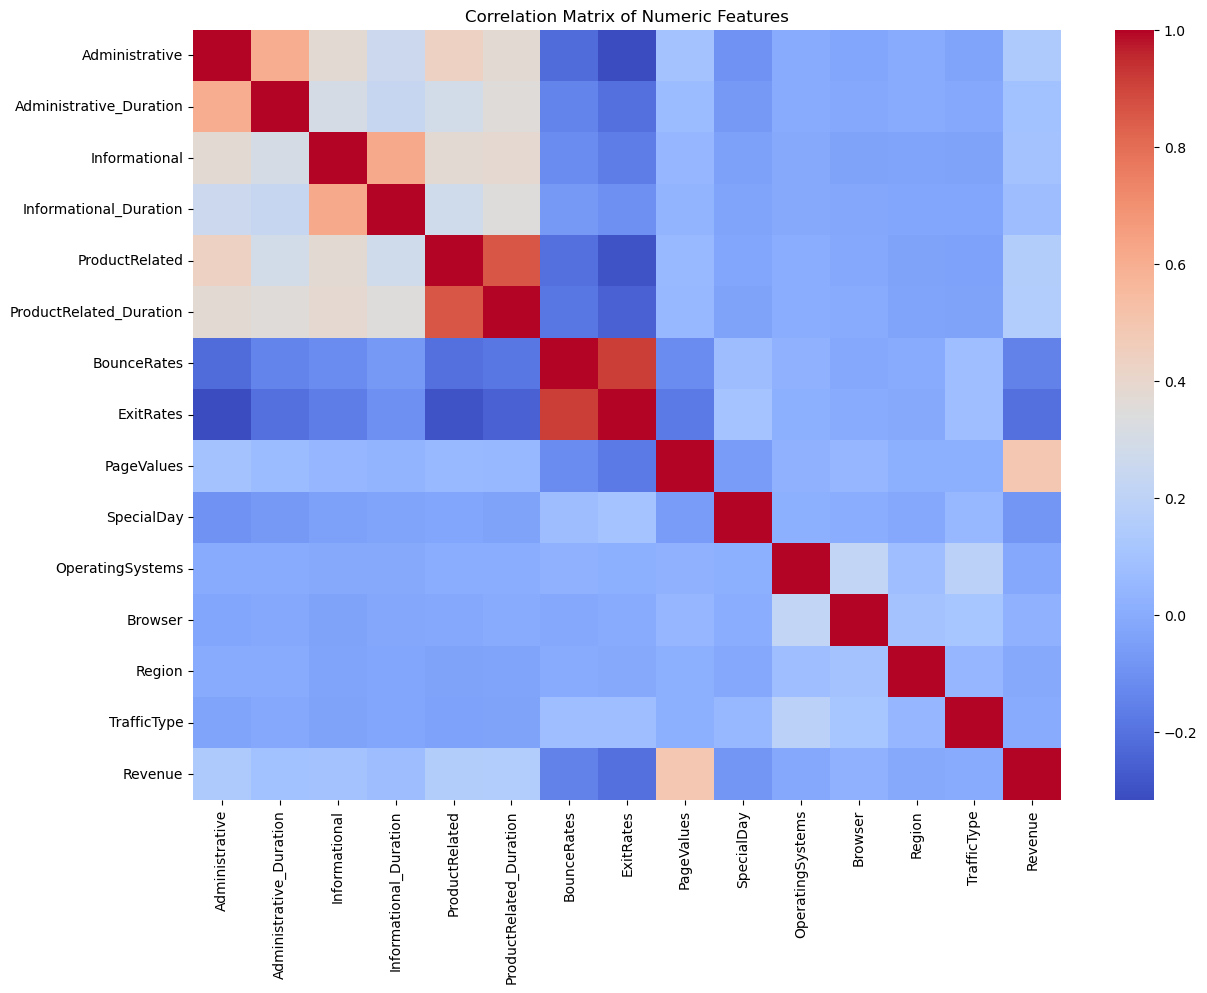

In [79]:
#2.7: CORRELATION ANALYSIS (Numeric Only)

corr_df = df[num_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_df, cmap='coolwarm', annot=False)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

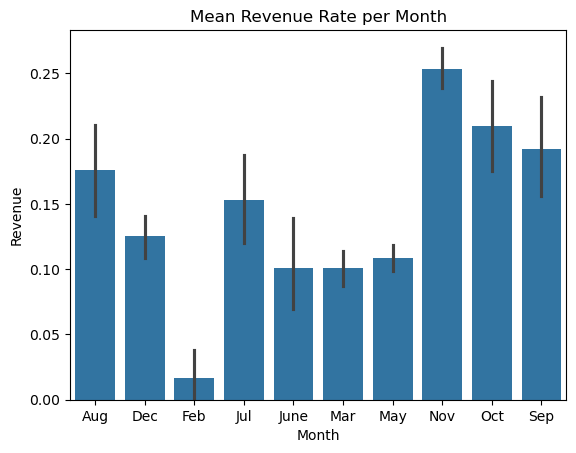

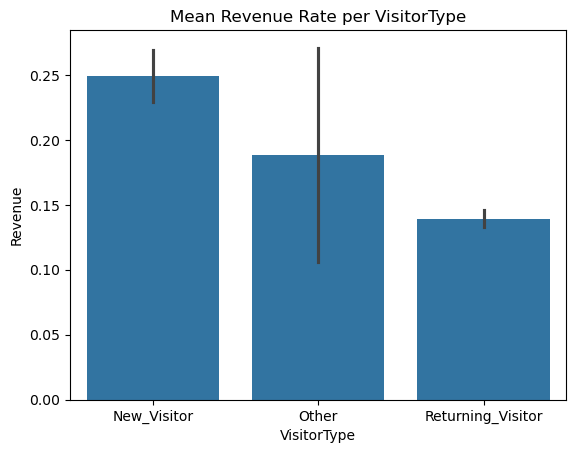

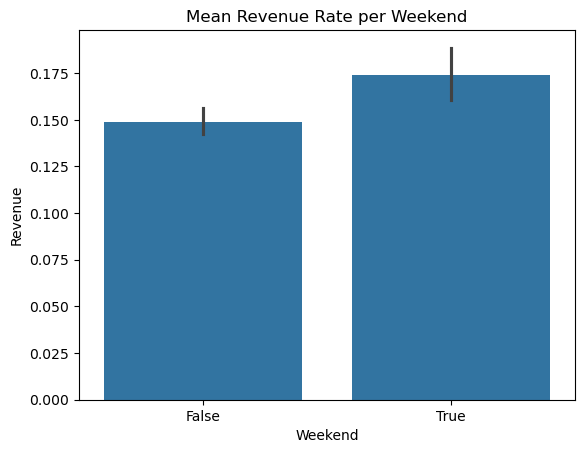

In [80]:
#2.8: TARGET RELATIONSHIPS (Revenue vs Predictors)

  ## Categorical variables vs Revenue
for col in cat_cols:
    sns.barplot(x=col, y='Revenue', data=df)
    plt.title(f"Mean Revenue Rate per {col}")
    plt.show()

In [83]:
                                                        SECTION 3 - INITIAL DATA PREPARATION
------------------------------------------------------------------------------------------------------------------------------------------------------

In [81]:
# PART 3: INITIAL DATA PREPARATION

# 3.1: Importing libraries

import pandas as pd


# 3.2 Remove duplicate rows

duplicates = df.duplicated().sum()
print("Duplicate rows before drop:", duplicates)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


# 3.3 Correct dtypes
#    Revenue → int (0/1)
#    Weekend → int (0/1)
#    Month, VisitorType → category


# Revenue & Weekend may be bool, string, or already numeric – handle robustly
for col in ['Revenue', 'Weekend']:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)
    else:
        df[col] = (
            df[col]
            .replace({'FALSE': 0, 'True': 1, 'TRUE': 1, 'False': 0})
            .astype(int)
        )

# Convert Month and VisitorType to category
df['Month'] = df['Month'].astype('category')
df['VisitorType'] = df['VisitorType'].astype('category')

print("\nDtypes after conversion:\n", df.dtypes)

Duplicate rows before drop: 125
Shape after removing duplicates: (12205, 18)

Dtypes after conversion:
 Administrative                int64
Administrative_Duration     float64
Informational                 int64
Informational_Duration      float64
ProductRelated                int64
ProductRelated_Duration     float64
BounceRates                 float64
ExitRates                   float64
PageValues                  float64
SpecialDay                  float64
Month                      category
OperatingSystems              int64
Browser                       int64
Region                        int64
TrafficType                   int64
VisitorType                category
Weekend                       int64
Revenue                       int64
dtype: object


In [83]:
# 3.4 Missing values check

missing_count = df.isnull().sum()
print("\nMissing values per column:\n", missing_count)


# 3.5 Outlier & range validation
#    (no modifications, just checks)

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumeric summary:\n", df[numeric_cols].describe().T)

# 3.6 Check for negative values in duration/count/page-related columns

duration_like_cols = [
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration',
    'Administrative',
    'Informational',
    'ProductRelated',
    'PageValues',
    'SpecialDay'
]

for col in duration_like_cols:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        print(f"{col}: negative values count = {neg_count}")

# 3.7 Check BounceRates / ExitRates within [0, 1]
rate_cols = ['BounceRates', 'ExitRates']
for col in rate_cols:
    below_zero = (df[col] < 0).sum()
    above_one = (df[col] > 1).sum()
    print(f"{col}: values < 0 = {below_zero}, values > 1 = {above_one}")


# 3.8 Create Total_Duration feature

duration_cols = [
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration'
]

df['Total_Duration'] = df[duration_cols].sum(axis=1)


Missing values per column:
 Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
Total_Duration             0
dtype: int64

Numeric summary:
                            count         mean          std  min         25%  \
Administrative           12205.0     2.338878     3.330436  0.0    0.000000   
Administrative_Duration  12205.0    81.646331   177.491845  0.0    0.000000   
Informational            12205.0     0.508726     1.275617  0.0    0.000000   
Informational_Duration   12205.0    34.825454   141.424807  0.0    0.000

In [84]:
# Preview the new feature
df[['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'Total_Duration']].head()

,Administrative_Duration,Informational_Duration,ProductRelated_Duration,Total_Duration
0,0.0,0.0,0.000000,0.000000
1,0.0,0.0,64.000000,64.000000
2,0.0,0.0,0.000000,0.000000
3,0.0,0.0,2.666667,2.666667
4,0.0,0.0,627.500000,627.500000


In [93]:
# 3.9 Create Purchase Intent Stage (Browsing / Consideration / HighIntent)

   
# Rules are based on session behaviour (e.g. product page views, durations, and revenue outcome).
# Detailed justification of thresholds is provided in the written report.


# Default: Browsing
df['Stage'] = 'Browsing'

# High purchase intent: strong product focus OR actual purchase (Revenue=1)
high_intent_mask = (
    (df["Revenue"] == 1) |
    (
        (df["ProductRelated"] >= 10) &
        (df["ProductRelated_Duration"] >= 300) &   # 5+ minutes
        (df["PageValues"] > 0)
    )
)

# Consideration: above browsing, but not as strong as HighIntent
consideration_mask = (
    (df["Revenue"] == 0) &
    (df["ProductRelated"] >= 5) &
    (df["ProductRelated_Duration"] >= 120)        # 2+ minutes
)


# Apply HighIntent first
df.loc[high_intent_mask, "Stage"] = "HighIntent"

# Then Consideration, but only where not already HighIntent
df.loc[consideration_mask & ~high_intent_mask, "Stage"] = "Consideration"

df["Stage"] = df["Stage"].astype("category")

print(df["Stage"].value_counts())
print("\nStage distribution (%):")
print(df["Stage"].value_counts(normalize=True).round(3))

Stage
Consideration    6715
HighIntent       3053
Browsing         2437
Name: count, dtype: int64

Stage distribution (%):
Stage
Consideration    0.55
HighIntent       0.25
Browsing         0.20
Name: proportion, dtype: float64


In [94]:
# 3.10 Save Clean Base Dataset 

# Save the cleaned dataset to a new CSV file
df.to_csv("D:\group_19\V3\clean_online_shoppers_intention.csv", index=False)

print("Cleaned dataset saved as: clean_online_shoppers_intention.csv")

Cleaned dataset saved as: clean_online_shoppers_intention.csv


In [ ]:
                                                SECTION - 4 - ITERATIVE PROCESS

In [12]:

# PART 4. ITERATIVE PROCESS – MODELING PIPELINE

# 4.1 Imports & global paths
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

import joblib

# --- Paths (adjust only if you move files) ---
DATA_PATH  = "clean_online_shoppers_intention.csv"   # your cleaned dataset
OUTPUT_DIR = "model_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# 4.2 Load cleaned dataset

df_model = pd.read_csv(DATA_PATH)

print("Loaded cleaned dataset.")
print("Shape:", df_model.shape)
print("Columns:", df_model.columns.tolist())

# 4.3 Create Stage (target variable)


# Default: Browsing
df_model["Stage"] = "Browsing"

# High purchase intent: strong product focus OR actual purchase (Revenue=1)
high_intent_mask = (
    (df_model["Revenue"] == 1) |
    (
        (df_model["ProductRelated"] >= 10) &
        (df_model["ProductRelated_Duration"] >= 300) &   # 5+ minutes
        (df_model["PageValues"] > 0)
    )
)

# Consideration: above browsing, but not as strong as HighIntent
consideration_mask = (
    (df_model["Revenue"] == 0) &
    (df_model["ProductRelated"] >= 5) &
    (df_model["ProductRelated_Duration"] >= 120)        # 2+ minutes
)

# Apply HighIntent first
df_model.loc[high_intent_mask, "Stage"] = "HighIntent"

# Then Consideration, but only where not already HighIntent
df_model.loc[consideration_mask & ~high_intent_mask, "Stage"] = "Consideration"

# Cast to category
df_model["Stage"] = df_model["Stage"].astype("category")

print("\nStage value counts:")
print(df_model["Stage"].value_counts())
print("\nStage distribution (%):")
print(df_model["Stage"].value_counts(normalize=True).round(3))

# 4.4 Add behavioural features


def add_behavior_features(df_in: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure key behaviour features exist.
    Safe to call multiple times (only creates missing columns).
    """
    df = df_in.copy()

    # Total duration across main page types
    if "Total_Duration" not in df.columns:
        df["Total_Duration"] = (
            df["Administrative_Duration"]
            + df["Informational_Duration"]
            + df["ProductRelated_Duration"]
        )

    # Engagement score: simple heuristic combining value and time
    if "Engagement_Score" not in df.columns:
        df["Engagement_Score"] = (
            df["PageValues"].fillna(0)
            + df["Total_Duration"].fillna(0) / 60.0  # minutes
        )

    # Navigation intensity: total number of page visits
    if "Navigation_Intensity" not in df.columns:
        df["Navigation_Intensity"] = (
            df["Administrative"] + df["Informational"] + df["ProductRelated"]
        )

    return df

df_model = add_behavior_features(df_model)

print("\nAfter adding behavioural features, columns are:")
print(df_model.columns.tolist())

Loaded cleaned dataset.
Shape: (12330, 19)
Columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue', 'Total_Duration']

Stage value counts:
Stage
Consideration    6715
HighIntent       3053
Browsing         2562
Name: count, dtype: int64

Stage distribution (%):
Stage
Consideration    0.545
HighIntent       0.248
Browsing         0.208
Name: proportion, dtype: float64

After adding behavioural features, columns are:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue', 'Total_Duration', 'Stage', 'Engagement_Score'

In [13]:
# 4.5 Helper: train/test split + encoding

from typing import Tuple

def get_base_data(df_in: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Prepare base modelling data:
    - Target: Stage (Browsing / Consideration / HighIntent)
    - Drop target and Revenue from features to avoid leakage
    - One-hot encode remaining categorical variables
    - Train/test split with stratification
    """
    df = df_in.copy()

    # --- Target check ---
    if "Stage" not in df.columns:
        raise ValueError("Column 'Stage' not found – make sure it was created correctly.")

    # Target
    y = df["Stage"]

    # Drop Stage and Revenue from features to avoid leaking label & final outcome
    drop_cols = ["Stage"]
    if "Revenue" in df.columns:
        drop_cols.append("Revenue")

    X = df.drop(columns=drop_cols)

    # --- One-hot encode categorical columns ---
    cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns
    if len(cat_cols) > 0:
        X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    # --- Train/Test split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y,
    )

    print("\nX_train shape:", X_train.shape)
    print("X_test  shape:", X_test.shape)
    print("\ny_train distribution:\n", y_train.value_counts())
    print("\ny_test distribution:\n", y_test.value_counts())

    return X_train, X_test, y_train, y_test

In [14]:
# 4.6 Helper: evaluation function

def evaluate_model(name: str, y_true, y_pred) -> None:
    """
    Prints classification report and plots confusion matrix
    for staged purchase intent classification.
    """
    print(f"\n===== {name} – CLASSIFICATION REPORT =====\n")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_true.unique()))
    plt.figure(figsize=(6,5))
    disp.plot(values_format='d', cmap="Blues")
    plt.title(f"{name} – Confusion Matrix")
    plt.tight_layout()
    plt.show()


X_train shape: (9864, 29)
X_test  shape: (2466, 29)

y_train distribution:
 Stage
Consideration    5372
HighIntent       2442
Browsing         2050
Name: count, dtype: int64

y_test distribution:
 Stage
Consideration    1343
HighIntent        611
Browsing          512
Name: count, dtype: int64

===== Baseline – DummyClassifier (most_frequent) – CLASSIFICATION REPORT =====

               precision    recall  f1-score   support

     Browsing       0.00      0.00      0.00       512
Consideration       0.54      1.00      0.71      1343
   HighIntent       0.00      0.00      0.00       611

     accuracy                           0.54      2466
    macro avg       0.18      0.33      0.24      2466
 weighted avg       0.30      0.54      0.38      2466



C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 600x500 with 0 Axes>

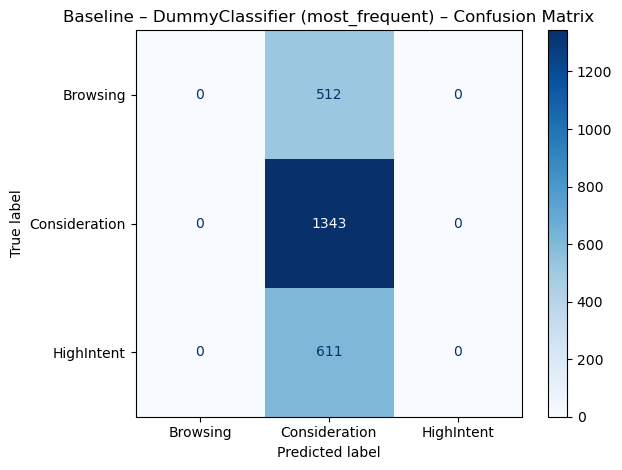

In [15]:
# --------------------------------------------
# Iteration 0 – Baseline Dummy Classifier
# --------------------------------------------

from sklearn.dummy import DummyClassifier

# Baseline – most frequent class
X_train, X_test, y_train, y_test = get_base_data(df_model)

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)

evaluate_model("Baseline – DummyClassifier (most_frequent)", y_test, y_pred_dummy)


X_train shape: (9864, 29)
X_test  shape: (2466, 29)

y_train distribution:
 Stage
Consideration    5372
HighIntent       2442
Browsing         2050
Name: count, dtype: int64

y_test distribution:
 Stage
Consideration    1343
HighIntent        611
Browsing          512
Name: count, dtype: int64


C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Iteration 1 – Logistic Regression (Baseline) – CLASSIFICATION REPORT =====

               precision    recall  f1-score   support

     Browsing       0.88      0.93      0.90       512
Consideration       0.90      0.94      0.92      1343
   HighIntent       0.96      0.82      0.88       611

     accuracy                           0.91      2466
    macro avg       0.91      0.90      0.90      2466
 weighted avg       0.91      0.91      0.91      2466



<Figure size 600x500 with 0 Axes>

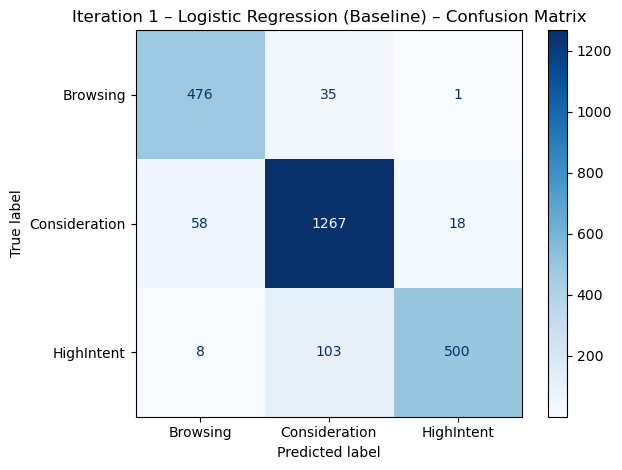

In [16]:
# ITERATION 1: Multinomial Logistic Regression

# Use dataset as produced by EDA + Data Prep
# ITERATION 1: Multinomial Logistic Regression (Baseline)
# ----------------------------------------------------------
# This iteration establishes a strong linear baseline model
# for the multi-class purchase intent classification problem.
#
# Logistic Regression is appropriate as a first step because:
# - It is simple and interpretable
# - It provides a benchmark for non-linear models later
# - It helps confirm whether the data is linearly separable
#
# A Pipeline is used to standardise features before fitting
# the classifier, which stabilises optimisation and improves
# model convergence.

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ----------------------------------------------------------
# Step 1: Create train/test split using the shared base loader
# ----------------------------------------------------------
# get_base_data() performs:
# - Target selection (Stage)
# - Leakage prevention (removes Revenue)
# - One-hot-encoding of categoricals
# - Stratified train/test split

X_train, X_test, y_train, y_test = get_base_data(df_model)


# Step 2: Define the Logistic Regression pipeline

# StandardScaler is used to normalise numeric inputs so that
# Logistic Regression's gradient-based solver converges faster
# and avoids being biased by features with large numerical ranges.
#
# multi_class='multinomial' ensures the use of softmax for
# proper 3-class probability modeling.

log_reg = Pipeline(steps=[
    ('scaler', StandardScaler()),     # if X is dense
    ('clf', LogisticRegression(
        max_iter=2000,
        multi_class="multinomial",
        n_jobs=-1
    ))
])

# Step 3: Fit the model on training data

log_reg.fit(X_train, y_train)

#Step 4: Predict test set and Evaluate

y_pred_lr = log_reg.predict(X_test)
evaluate_model("Iteration 1 – Logistic Regression (Baseline)", y_test, y_pred_lr)


X_train shape: (9864, 29)
X_test  shape: (2466, 29)

y_train distribution:
 Stage
Consideration    5372
HighIntent       2442
Browsing         2050
Name: count, dtype: int64

y_test distribution:
 Stage
Consideration    1343
HighIntent        611
Browsing          512
Name: count, dtype: int64

Class distribution in y_train (before any handling):
Stage
Consideration    0.544607
HighIntent       0.247567
Browsing         0.207826
Name: proportion, dtype: float64

===== Iteration 2 – Decision Tree (balanced class_weight) – CLASSIFICATION REPORT =====

               precision    recall  f1-score   support

     Browsing       0.99      0.96      0.97       512
Consideration       0.97      0.95      0.96      1343
   HighIntent       0.86      0.92      0.89       611

     accuracy                           0.94      2466
    macro avg       0.94      0.94      0.94      2466
 weighted avg       0.94      0.94      0.94      2466



<Figure size 600x500 with 0 Axes>

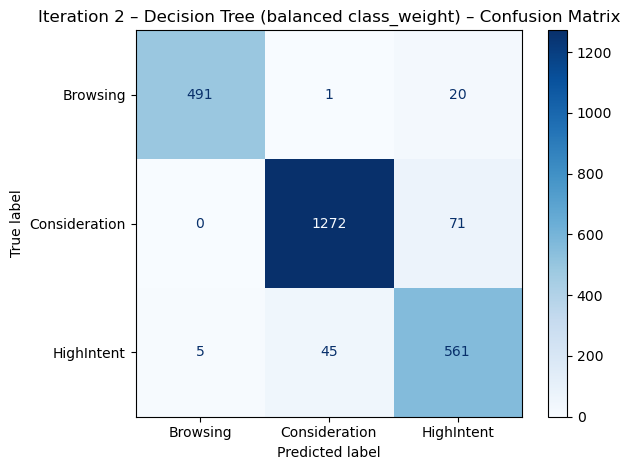

In [126]:
# ITERATION 2: Decision Tree (class_weight balanced)


X_train, X_test, y_train, y_test = get_base_data(df_model)

print("\nClass distribution in y_train (before any handling):")
print(y_train.value_counts(normalize=True))

# Use class_weight='balanced' so the tree internally compensates for imbalance
dt_clf = DecisionTreeClassifier(
    random_state=42,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    class_weight='balanced'   # <--- THIS replaces SMOTE
)

# Train the model

dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test) # Predict test labels

evaluate_model("Iteration 2 – Decision Tree (balanced class_weight)", y_test, y_pred_dt)



X_train shape: (9864, 29)
X_test  shape: (2466, 29)

y_train distribution:
 Stage
Consideration    5372
HighIntent       2442
Browsing         2050
Name: count, dtype: int64

y_test distribution:
 Stage
Consideration    1343
HighIntent        611
Browsing          512
Name: count, dtype: int64

Class distribution in y_train:
Stage
Consideration    0.544607
HighIntent       0.247567
Browsing         0.207826
Name: proportion, dtype: float64

===== Iteration 3 – Random Forest (class_weight balanced) – CLASSIFICATION REPORT =====

               precision    recall  f1-score   support

     Browsing       0.99      1.00      1.00       512
Consideration       0.96      0.99      0.98      1343
   HighIntent       0.99      0.91      0.95       611

     accuracy                           0.97      2466
    macro avg       0.98      0.97      0.97      2466
 weighted avg       0.97      0.97      0.97      2466



<Figure size 600x500 with 0 Axes>

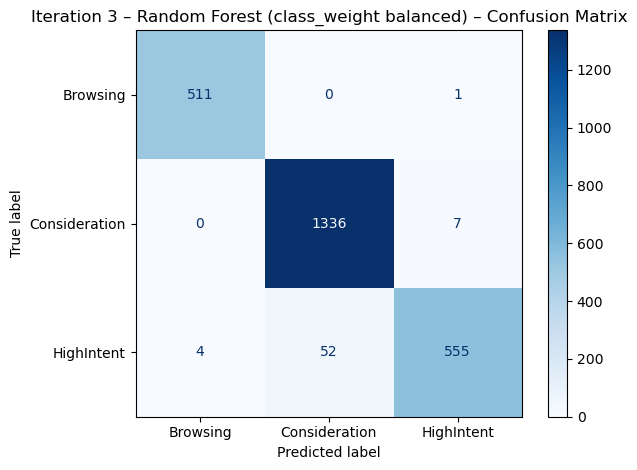


Top 15 feature importances:
PageValues                 0.269047
ProductRelated_Duration    0.155916
Engagement_Score           0.147490
ProductRelated             0.115500
Total_Duration             0.082683
Navigation_Intensity       0.078886
ExitRates                  0.036660
BounceRates                0.022623
Administrative_Duration    0.019709
Administrative             0.016053
Month_Nov                  0.007350
TrafficType                0.006892
Informational_Duration     0.006605
Region                     0.006257
Informational              0.005053
dtype: float64


In [127]:
# ITERATION 3: Random Forest (class_weight balanced)

X_train, X_test, y_train, y_test = get_base_data(df_model)

print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))

# Random Forest with internal class balancing (no SMOTE)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'   # < replaces SMOTE
)

# Train model ^ Predict test labels

rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

evaluate_model("Iteration 3 – Random Forest (class_weight balanced)", y_test, y_pred_rf)

# Display top feature importances
feat_importances = pd.Series(
    rf_clf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 15 feature importances:")
print(feat_importances.head(15))


X_train shape: (9864, 29)
X_test  shape: (2466, 29)

y_train distribution:
 Stage
Consideration    5372
HighIntent       2442
Browsing         2050
Name: count, dtype: int64

y_test distribution:
 Stage
Consideration    1343
HighIntent        611
Browsing          512
Name: count, dtype: int64

Class distribution in y_train (Iteration 4):
Stage
Consideration    0.544607
HighIntent       0.247567
Browsing         0.207826
Name: proportion, dtype: float64

===== Iteration 4 – RF + Feature Engineering (class_weight balanced) – CLASSIFICATION REPORT =====

               precision    recall  f1-score   support

     Browsing       0.99      1.00      1.00       512
Consideration       0.96      0.99      0.98      1343
   HighIntent       0.99      0.91      0.95       611

     accuracy                           0.97      2466
    macro avg       0.98      0.97      0.97      2466
 weighted avg       0.97      0.97      0.97      2466



<Figure size 600x500 with 0 Axes>

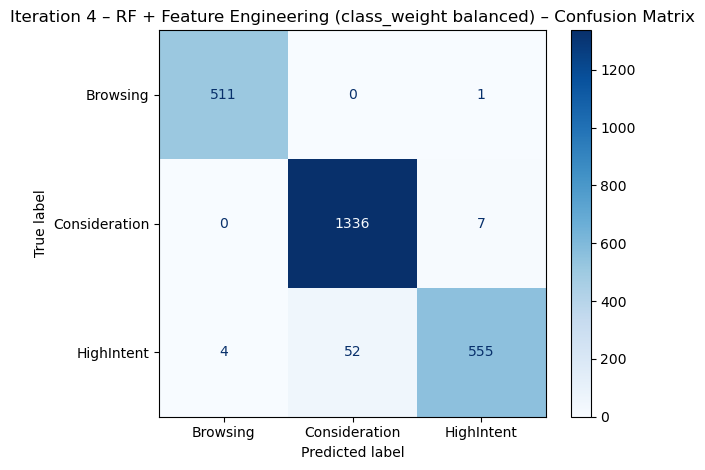


Top 15 feature importances (Iteration 4):
PageValues                 0.269047
ProductRelated_Duration    0.155916
Engagement_Score           0.147490
ProductRelated             0.115500
Total_Duration             0.082683
Navigation_Intensity       0.078886
ExitRates                  0.036660
BounceRates                0.022623
Administrative_Duration    0.019709
Administrative             0.016053
Month_Nov                  0.007350
TrafficType                0.006892
Informational_Duration     0.006605
Region                     0.006257
Informational              0.005053
dtype: float64


In [128]:
# ITERATION 4: Random Forest + Feature Engineering (balanced)

# df_fe: dataset with extra behavioural features (e.g. Total_Duration, Time_Per_Page, Engagement_Score, etc.)

df_fe = add_behavior_features(df_model)     

X_train, X_test, y_train, y_test = get_base_data(df_fe)

print("\nClass distribution in y_train (Iteration 4):")
print(y_train.value_counts(normalize=True))

# Random Forest with added behaviour features and balanced class weights

rf_fe_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'   # <-- imbalance handling instead of SMOTE
)

rf_fe_clf.fit(X_train, y_train)
y_pred_rf_fe = rf_fe_clf.predict(X_test)

evaluate_model("Iteration 4 – RF + Feature Engineering (class_weight balanced)", y_test, y_pred_rf_fe)

# Top 15 engineered feature importances
feat_importances_fe = pd.Series(
    rf_fe_clf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 15 feature importances (Iteration 4):")
print(feat_importances_fe.head(15))

In [ ]:
                                                SECTION - 5 - FINAL MODEL & EVALUATION


X_train shape: (9864, 29)
X_test  shape: (2466, 29)

y_train distribution:
 Stage
Consideration    5372
HighIntent       2442
Browsing         2050
Name: count, dtype: int64

y_test distribution:
 Stage
Consideration    1343
HighIntent        611
Browsing          512
Name: count, dtype: int64

Final model – class distribution in y_train:
Stage
Consideration    0.544607
HighIntent       0.247567
Browsing         0.207826
Name: proportion, dtype: float64
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best parameters found:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

===== Iteration 5 – Tuned Random Forest (Best Model, class_weight balanced) – CLASSIFICATION REPORT =====

               precision    recall  f1-score   support

     Browsing       0.99      1.00      1.00       512
Consideration       0.96      1.00      0.98      1343
   HighIntent       0.99      0.91      0.95       611

     accuracy                           

<Figure size 600x500 with 0 Axes>

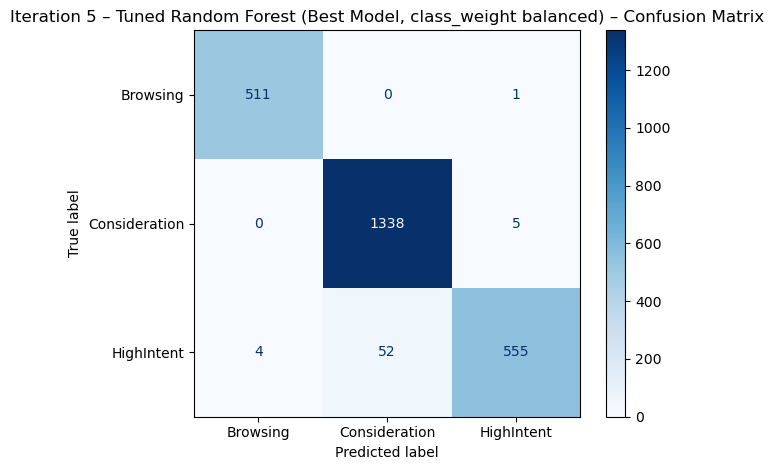

In [129]:
# 5. TUNED RANDOM FOREST

# Ensure we're using the prepared modelling dataset
X_train, X_test, y_train, y_test = get_base_data(df_model)

print("\nFinal model – class distribution in y_train:")
print(y_train.value_counts(normalize=True))

# Hyperparameter grid (kept reasonably small for runtime)
param_grid = {
    "n_estimators":      [100, 200],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf":  [1, 2],
}

# Base Random Forest with internal class balancing

base_rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"   # imbalance handling instead of SMOTE
)

# Grid search with 3-fold CV using macro-F1 for multi-class imbalance

grid_rf = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",   # good for multi-class with imbalance
    n_jobs=-1,
    verbose=2
)

# Train all model
grid_rf.fit(X_train, y_train)

print("\nBest parameters found:")
print(grid_rf.best_params_)

# Retrieve the best-performing model

best_rf = grid_rf.best_estimator_

# Predict on the test set

y_pred_best = best_rf.predict(X_test)

evaluate_model(
    "Iteration 5 – Tuned Random Forest (Best Model, class_weight balanced)",
    y_test,
    y_pred_best
)

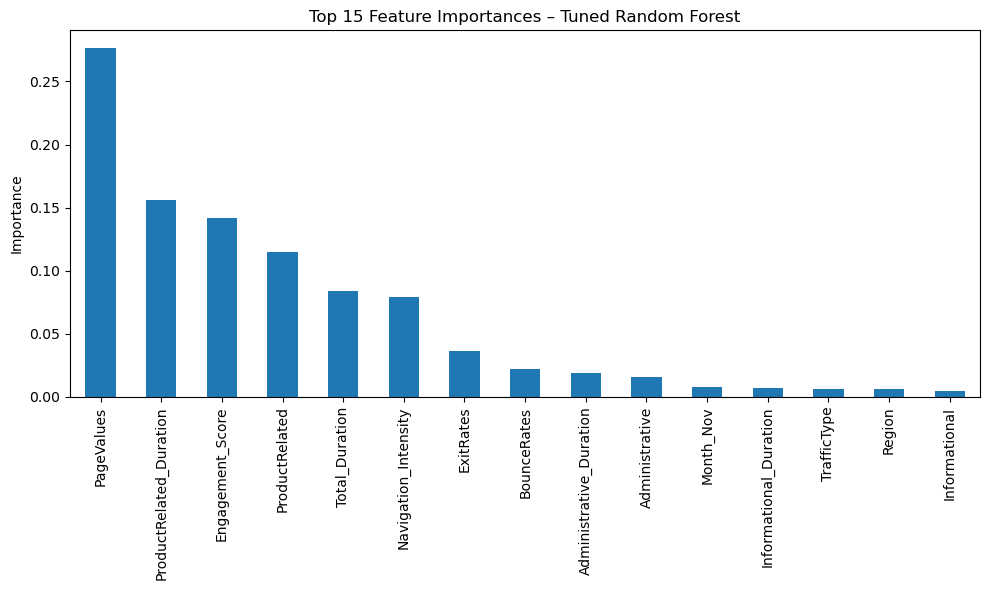

In [130]:
# Feature importances for the final Random Forest
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=False)

# Plot the top 15 important predictors

plt.figure(figsize=(10, 6))
importances_sorted.head(15).plot(kind="bar")
plt.title("Top 15 Feature Importances – Tuned Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()
